# Priors for maximal information transfer in the Sinusoids Environment 
## Problem Statement
Define arbitrary prior on neural network parameters $\theta$ 
for optimal information transfer. That is, knowing 
that our data is generated from the function class
$$
\mathcal F := \{f: f(x)=\alpha \sin (x) \}
$$
translate this into a distribution over the parameters $p(\theta)$ such that the posterior is Gaussian with mean $f(x)$ and variance $\Sigma$.

In [141]:
import numpy as np
import matplotlib
from matplotlib import figure
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp

tfd = tfp.distributions
tfpl = tfp.layers

from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import MeanSquaredError


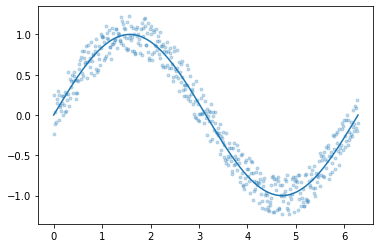

In [146]:
n = 500
eps = .5 * (np.random.rand(n)-.5)

x_train = np.linspace(0, 2*np.pi, n)
y_train = np.sin(x_train) + eps
y_true = np.sin(x_train)
plt.scatter(x_train, y_train, marker='.', alpha=.25)
plt.plot(x_train, y_true)
plt.show()

### Method 1: Fitting an independent multivariate normal and learning $\mu$ and $\sigma$

In [148]:
def nll(y_true, y_pred):
    return -y_pred.log_prob(y_true)

model = tf.keras.models.Sequential([
    tf.keras.layers.InputLayer(1),
    tf.keras.layers.Dense(4, activation='tanh'),
    tf.keras.layers.Dense(4, activation='tanh'),
    tf.keras.layers.Dense(tfpl.IndependentNormal.params_size(event_shape=1)),  # 2 parameters
    tfpl.IndependentNormal(event_shape=1),
])

model.compile(loss=nll, optimizer=RMSprop(0.01))
model.fit(x_train, y_train, epochs=750, verbose=False)

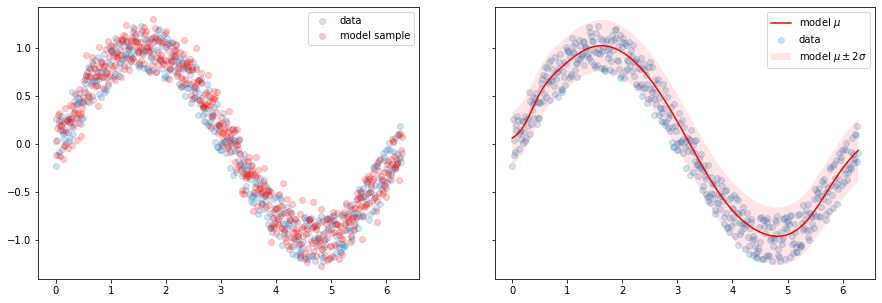

In [149]:
y_model = model(x_train)
y_sample = y_model.sample()
y_hat = y_model.mean()
y_sd = y_model.stddev()
y_hat_m2sd = y_hat - 2 * y_sd
y_hat_p2sd = y_hat + 2 * y_sd

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

ax1.scatter(x_train, y_train, alpha=0.2, label='data')
ax1.scatter(x_train, y_sample, alpha=0.2, color='r', label='model sample')
ax1.legend()

# ax2.plot(x_train, y_true, '--', label='true')
ax2.scatter(x_train, y_train, alpha=0.2, label='data')
ax2.plot(x_train, y_hat, color='r', label='model $\mu$')
ax2.fill_between(x_train, np.squeeze(y_hat_m2sd), np.squeeze(y_hat_p2sd), 
                 facecolor='r', alpha=0.1, label='model $\mu \pm 2 \sigma$')

ax2.legend()

plt.show()

*Aleatoric* uncertainty is solved. *Epistemic* uncertainty however seems to be a problem.

### Method 2: Using variational inference with sinusoidal prior over parameters using `DenseVariational` probabilistic layer

In [ ]:
def prior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    prior_model = Sequential([
        tfpl.DistributionLambda(lambda t: tfd.Normal(tf.zeros(n), tf.ones(n)))
    ])
    return prior_model

def posterior(kernel_size, bias_size, dtype=None):
    n = kernel_size + bias_size
    posterior_model = Sequential([
        tfpl.VariableLayer(tfpl.IndependentNormal.params_size(n), dtype=dtype),  # Simply returns a (trainable) variable, regardless of input.
        tfpl.IndependentNormal(),
    ])
    return posterior_model

In [ ]:
model = Sequential([
    tfpl.DenseVariational(
        1, 
        input_shape=(1,), 
        make_prior_fn=prior, 
        make_posterior_fn=posterior, 
        kl_weight=1/x_train.shape[0],
        kl_use_exact=True
    )
])
model.compile(loss=MeanSquaredError(), optimizer=RMSprop(.005))
model.fit(x_train,y_train, epochs=100, verbose=False)

In [ ]:
plt.scatter(x_train, y_train, alpha=0.2, label='data')
for _ in range(30):
    y_model = model(x_train)
    plt.plot(x_train, y_model, color='red', alpha=0.1)        
plt.legend()
plt.show()

In [ ]:
y_model = model(x_train)
y_sample = y_model.sample()
y_hat = y_model.mean()
y_sd = y_model.stddev()
y_hat_m2sd = y_hat - 2 * y_sd
y_hat_p2sd = y_hat + 2 * y_sd

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

ax1.scatter(x_train, y_train, alpha=0.2, label='data')
ax1.scatter(x_train, y_sample, alpha=0.2, color='r', label='model sample')
ax1.legend()

# ax2.plot(x_train, y_true, '--', label='true')
ax2.scatter(x_train, y_train, alpha=0.2, label='data')
ax2.plot(x_train, y_hat, color='r', label='model $\mu$')
ax2.fill_between(x_train, np.squeeze(y_hat_m2sd), np.squeeze(y_hat_p2sd), 
                 facecolor='r', alpha=0.1, label='model $\mu \pm 2 \sigma$')

ax2.legend()

plt.show()

## Method 3: Generative models - `Bijector` objects

## Method 4: Gaussian Process Regression

In [ ]:

posterior = tfd.GaussianProcessRegressionModel(
    kernel=tfp.math.psd_kernels.ExponentiatedQuadratic(),
    index_points=tf.linspace(-3., 3., 200)[..., tf.newaxis],
    observation_index_points=x_train,
    observations=y_train,
    jitter=1e-5)

samples = posterior.sample(50)

In [139]:
psd_kernels = tfp.math.psd_kernels

# Generate noisy observations from a known function at some random points.
observation_noise_variance = .5

def f(x):
    return np.sin(10*x[..., 0]) * np.exp(-x[..., 0]**2)

observation_index_points = np.random.uniform(-1., 1., 50).reshape(-1, 1)
observations = (f(observation_index_points) + np.random.normal(0, np.sqrt(observation_noise_variance)))

index_points = np.linspace(-1., 1., 100).reshape(-1, 1)

kernel = psd_kernels.MaternFiveHalves()

gprm = tfd.GaussianProcessRegressionModel(
    kernel=kernel,
    index_points=index_points,
    observation_index_points=observation_index_points,
    observations=observations,
    observation_noise_variance=observation_noise_variance)

samples = gprm.sample(10)  # 10 independently drawn, joint samples at `index_points`

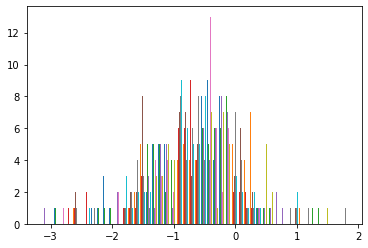

In [140]:
plt.hist(samples, bins=50)
plt.show()